## 7. Detección de relaciones entre las variables input continuas y las relaciones entre todas las variables input y las variables objetivo

In [2]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys

sys.path.append('functions')  # Make functions/FuncionesMineria.py importable
# Cargo las funciones que voy a utilizar despues
from FuncionesMineria import (graficoVcramer, mosaico_targetbinaria, boxplot_targetbinaria, 
                           hist_targetbinaria, Transf_Auto, lm, Rsq, validacion_cruzada_lm,
                           modelEffectSizes, crear_data_modelo, Vcramer, hist_target_categorica)


In [3]:
# Parto de los datos ya depurados
with open('data_clean/datosEleccionesDep.pickle', 'rb') as f:
    datos = pickle.load(f)

In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8117 entries, Abadía to Zuñeda
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   AbstencionAlta                8117 non-null   object 
 1   AbstentionPtge                8117 non-null   float64
 2   CodigoProvincia               8117 non-null   float64
 3   CCAA                          8117 non-null   object 
 4   Population                    8117 non-null   float64
 5   TotalCensus                   8117 non-null   float64
 6   Age_0-4_Ptge                  8117 non-null   float64
 7   Age_under19_Ptge              8117 non-null   float64
 8   Age_19_65_pct                 8117 non-null   float64
 9   Age_over65_pct                8117 non-null   float64
 10  WomanPopulationPtge           8117 non-null   float64
 11  ForeignersPtge                8117 non-null   float64
 12  SameComAutonPtge              8117 non-null   float64
 13  S

In [5]:

# Defino las variables objetivo y las elimino del conjunto de datos input
varObjCont = datos['AbstentionPtge']
varObjBin = datos['AbstencionAlta']
datos_input = datos.drop(['AbstentionPtge', 'AbstencionAlta'], axis = 1) 
 
# Genera una lista con los nombres de las variables.
variables_input = list(datos_input.columns)  

# Selecionamos las variables numéricas
numericas_input = datos_input.select_dtypes(include = ['int', 'int32', 'int64','float', 'float32', 'float64']).columns

# Selecionamos las variables categóricas
categoricas_input = [variable for variable in variables_input if variable not in numericas_input]

### Detección de relaciones entre variables continuas input

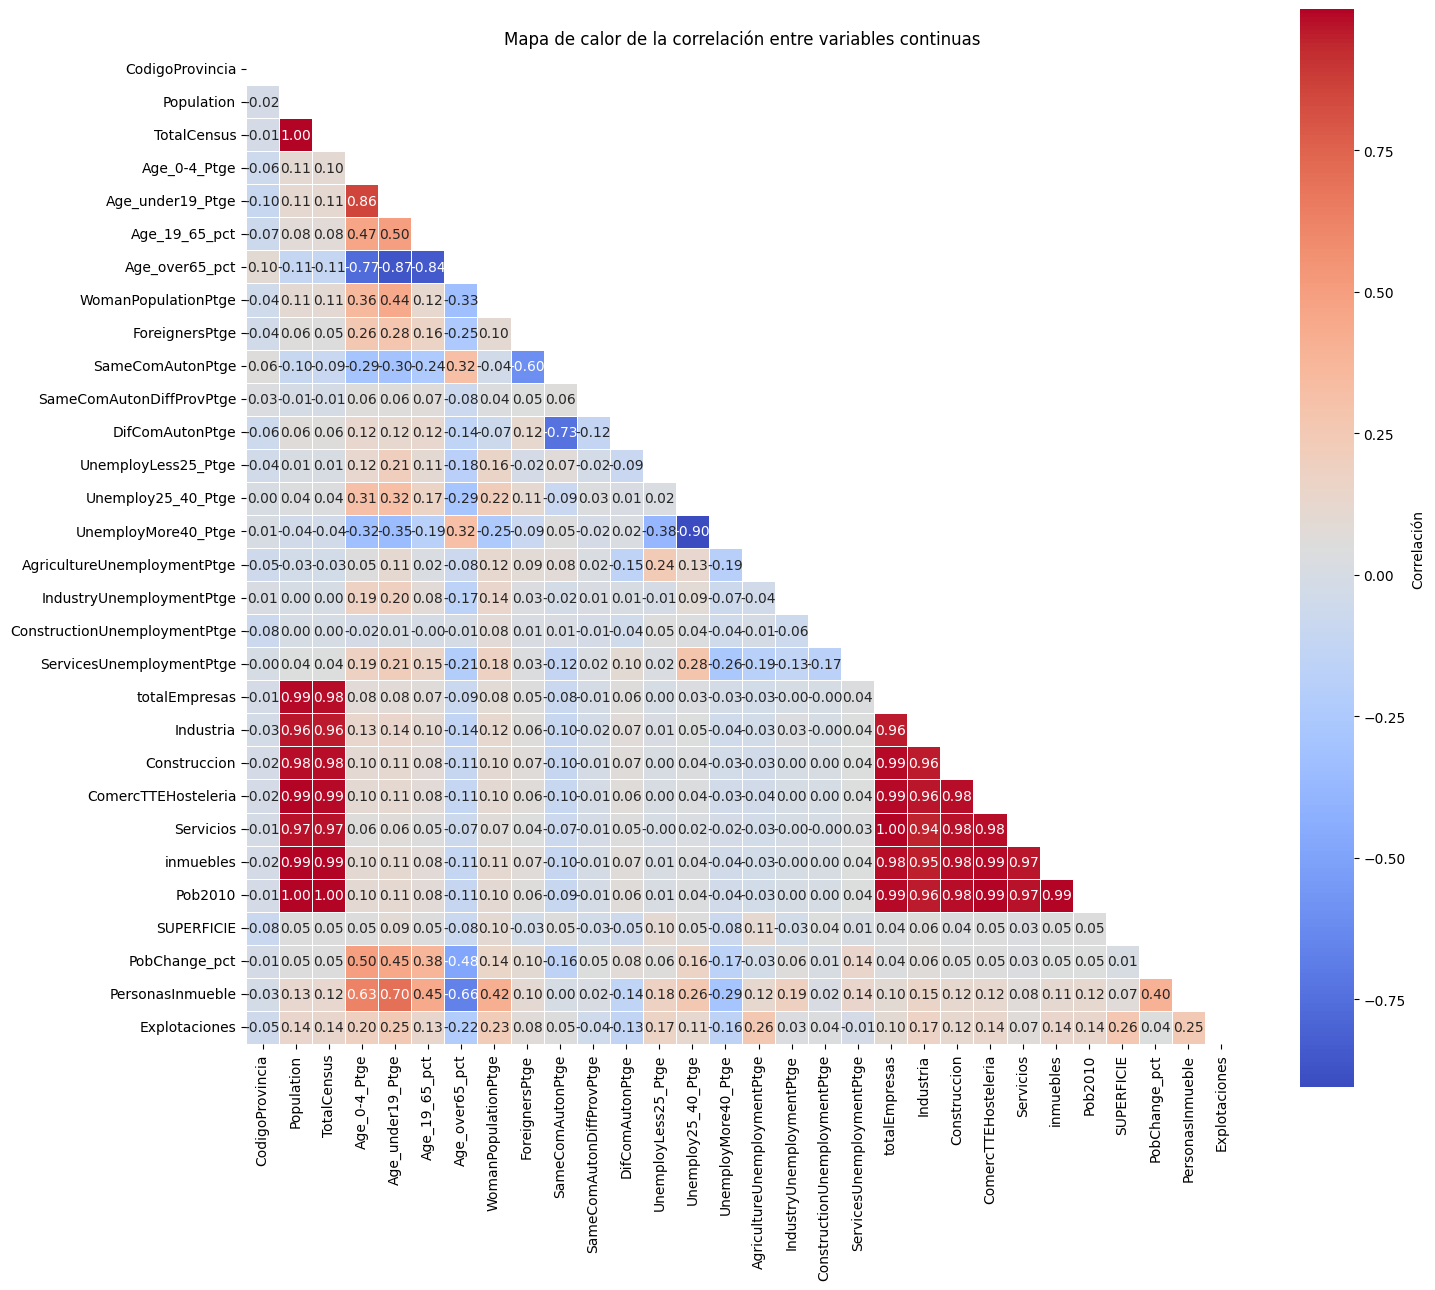

In [6]:


# Calcular la matriz de correlación
matriz_correlacion = datos_input[numericas_input].corr()

# Crear una máscara para la mitad superior
mask = np.triu(np.ones_like(matriz_correlacion, dtype=bool))

# Configurar el tamaño de la figura
plt.figure(figsize=(16, 14))

# Dibujar el mapa de calor con la máscara
sns.heatmap(matriz_correlacion, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            cbar_kws={'label': 'Correlación'}, square=True, linewidths=0.5, annot_kws={"size": 10})

plt.title('Mapa de calor de la correlación entre variables continuas')
plt.show()

Observamos como hay una relación totalmente lineal entre variables como Population, TotalCensus y Pob2010. Además, relaciones casi de 1 (>0.95) entre variables de población y totalcensus con el número de empresas por sector y por lo tanto el total de empresas. Esto quiere decir que: 
- A mayor población, el censo es mayor lo cual es lógico
- A mayor población, mayor número de empresas. 

Observamos otras relaciones curiosas:
 - El número de personas por inmueble está relacionado con el porcentaje de personas por rango de edad. Es decir, si hay mayor número de personas por deabjo de los 19 años, el número de personas por inmueble aumenta, lo cual tiene sentido ya que en esta edad las personas suelen vivir en casa de sus padres y por lo tanto un único inmueble es ocupado por varias personas, Al contrario, si el porcentaje de personas por encima de los 65 años aumenta, el n úmero de personas por inmueble disminuye, lo cual puede estar relacionado con que personas mayores opten por residencias en lugar de inmuebles propios. 
 - También hay una relación muy fuerte entre el número de empresas de distintos sectores. Es decir, parece ser que las empresas se encuentran en municipios específicos (grandes ciudades) donde no sólo se encuentran de un tipo sino de muchos.



### Relación entre variables input y objeivo

A continuación, utilizamos el estadístico V de Cramer para medir la relación entre las variables predictoras y las objetivo. Debido a como están creadas las funciones VCramer y graficoVcramer, podemos comparar cualquier variable predictora con las objetivo ya que las numéricas son discretizadas y convertidas a categóricas antes de calcular el estadístico. 

Idealmente se debería calcular la correlación para comparar variables numéricas, pero esta opción también nos permite visualizar y obtener una relación fiable entre variables. 

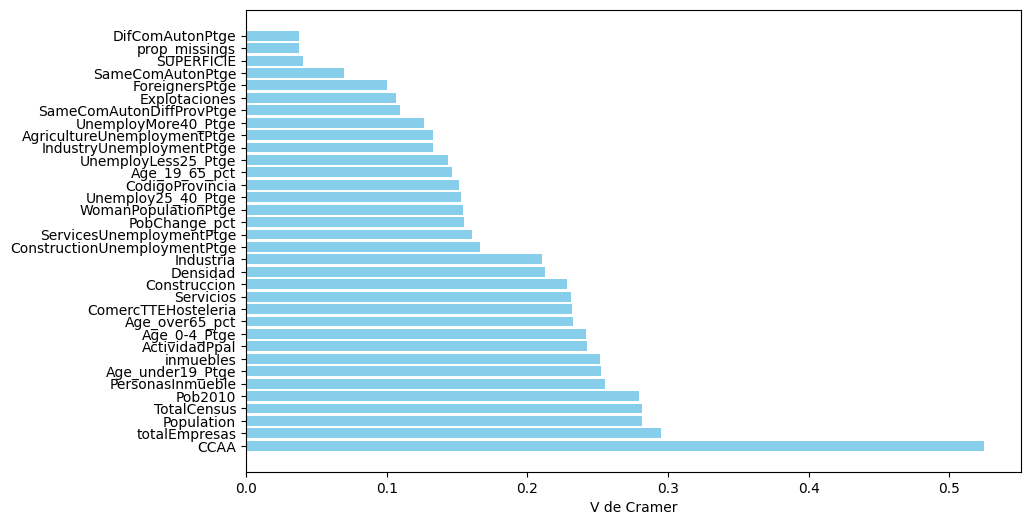

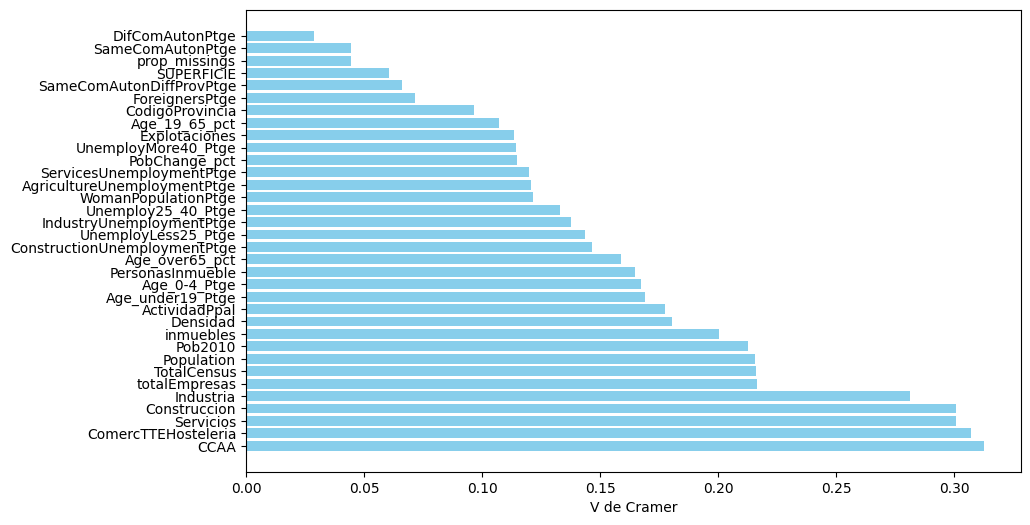

In [7]:
graficoVcramer(datos_input, varObjBin)
graficoVcramer(datos_input, varObjCont)

Como podemos observar en ambas gráficas, la relación entre la comunidad autónoma o el código de provincia con las variables objetivo es considerable. Sobre todo, para la target binaria AbstencionAlta. 

Es decir, el lugar desde donde se vota influye mucho en la decisión de abstenerse o no a ello. 

Por otro lado, variables como la proporción de missings o la superficie del municipio no influyen casi nada en las variables objetivo. Respecto a la superficie, tiene bastante sentido ya que siguiendo la lógica, no tiene un sentido razonable para influir en las votaciones. EN el caso de la proporción de valores faltantes, parece ser que tampoco influyen. Teniendo en cuenta que es una variable que no es propia del conjunto de datos original, podríamos pensar en eliminarla ya que no aporta mucha información. 

Por ahora, se decidió mantener las variablest tal y como están para observar los resultados que obtendremos en los modelos de regresión.

A continuación, se realiza el cálculo del V de cramer para almacenar los resultados

In [8]:
# Creamos una lista donde guardaremos los resultados
records = []

# Primer bucle: variable continua vs. varObjCont
for variable in variables_input:
    v_cramer = Vcramer(datos_input[variable], varObjCont)
    records.append({
        'Variable': variable,
        'Objetivo': varObjCont.name,
        'Vcramer': v_cramer
    })

# Segundo bucle: variable continua vs. varObjBin
for variable in variables_input:
    v_cramer = Vcramer(datos_input[variable], varObjBin)
    records.append({
        'Variable': variable,
        'Objetivo': varObjBin.name,
        'Vcramer': v_cramer
    })

# Convertimos la lista de diccionarios en un DataFrame
VCramer = pd.DataFrame(records)